# **GAME OF THRONES**:

La serie "A Song of Fire and Ice" consta de 5 libros, aunque parece ser que ya se está escribiendo un sexto "The Winds of Winter" y que se piensa en un séptimo "A Dream of Spring". El primero es "A Game of Thrones".

https://www.kaggle.com/mylesoneill/game-of-thrones

In [23]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn import metrics
from sklearn.preprocessing import StandardScaler

from google.colab import drive

In [24]:
drive.mount('/content/drive')

characters = pd.read_csv('/content/drive/MyDrive/Datasets/SAA/character-predictions.csv')
characters.info()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1946 entries, 0 to 1945
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   S.No               1946 non-null   int64  
 1   actual             1946 non-null   int64  
 2   pred               1946 non-null   int64  
 3   alive              1946 non-null   float64
 4   plod               1946 non-null   float64
 5   name               1946 non-null   object 
 6   title              938 non-null    object 
 7   male               1946 non-null   int64  
 8   culture            677 non-null    object 
 9   dateOfBirth        433 non-null    float64
 10  DateoFdeath        444 non-null    float64
 11  mother             21 non-null     object 
 12  father             26 non-null     object 
 13  heir               23 non-null     obje

# **DATA CLEANING**

In [25]:
# Vamos a quitar los siguientes atributos:

characters = characters.drop(['S.No', 'actual', 'pred', 'alive', 'plod'], axis=1)

In [26]:
porcentajes = (characters.isnull().sum()/len(characters))*100
porcentajes

,0
name,0.000000
title,51.798561
male,0.000000
culture,65.210689
dateOfBirth,77.749229
DateoFdeath,77.183967
mother,98.920863
father,98.663926
heir,98.818088
house,21.942446


In [27]:
# Quitamos aquellos atributos que tienen más de un 70 % de valores nulos

characters = characters.drop(['mother', 'father', 'heir', 'spouse', 'isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse'], axis=1)
characters = characters.drop(['dateOfBirth', 'DateoFdeath', 'age'], axis=1)

In [28]:
porcentajes = (characters.isnull().sum()/len(characters))*100
porcentajes

,0
name,0.000000
title,51.798561
male,0.000000
culture,65.210689
house,21.942446
book1,0.000000
book2,0.000000
book3,0.000000
book4,0.000000
book5,0.000000


In [29]:
characters.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1946 entries, 0 to 1945
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               1946 non-null   object 
 1   title              938 non-null    object 
 2   male               1946 non-null   int64  
 3   culture            677 non-null    object 
 4   house              1519 non-null   object 
 5   book1              1946 non-null   int64  
 6   book2              1946 non-null   int64  
 7   book3              1946 non-null   int64  
 8   book4              1946 non-null   int64  
 9   book5              1946 non-null   int64  
 10  isMarried          1946 non-null   int64  
 11  isNoble            1946 non-null   int64  
 12  numDeadRelations   1946 non-null   int64  
 13  boolDeadRelations  1946 non-null   int64  
 14  isPopular          1946 non-null   int64  
 15  popularity         1946 non-null   float64
 16  isAlive            1946 

In [30]:
# Simplificamos

cult = {
    'Summer Islands': ['summer islands', 'summer islander', 'summer isles'],
    'Ghiscari': ['ghiscari', 'ghiscaricari',  'ghis'],
    'Asshai': ["asshai'i", 'asshai'],
    'Lysene': ['lysene', 'lyseni'],
    'Andal': ['andal', 'andals'],
    'Braavosi': ['braavosi', 'braavos'],
    'Dornish': ['dornishmen', 'dorne', 'dornish'],
    'Myrish': ['myr', 'myrish', 'myrmen'],
    'Westermen': ['westermen', 'westerman', 'westerlands'],
    'Westerosi': ['westeros', 'westerosi'],
    'Stormlander': ['stormlands', 'stormlander'],
    'Norvoshi': ['norvos', 'norvoshi'],
    'Northmen': ['the north', 'northmen'],
    'Free Folk': ['wildling', 'first men', 'free folk'],
    'Qartheen': ['qartheen', 'qarth'],
    'Reach': ['the reach', 'reach', 'reachmen'],
    }

def get_cult(value):
    value = value.lower()
    v = [k for (k, v) in cult.items() if value in v]
    return v[0] if len(v) > 0 else value.title()

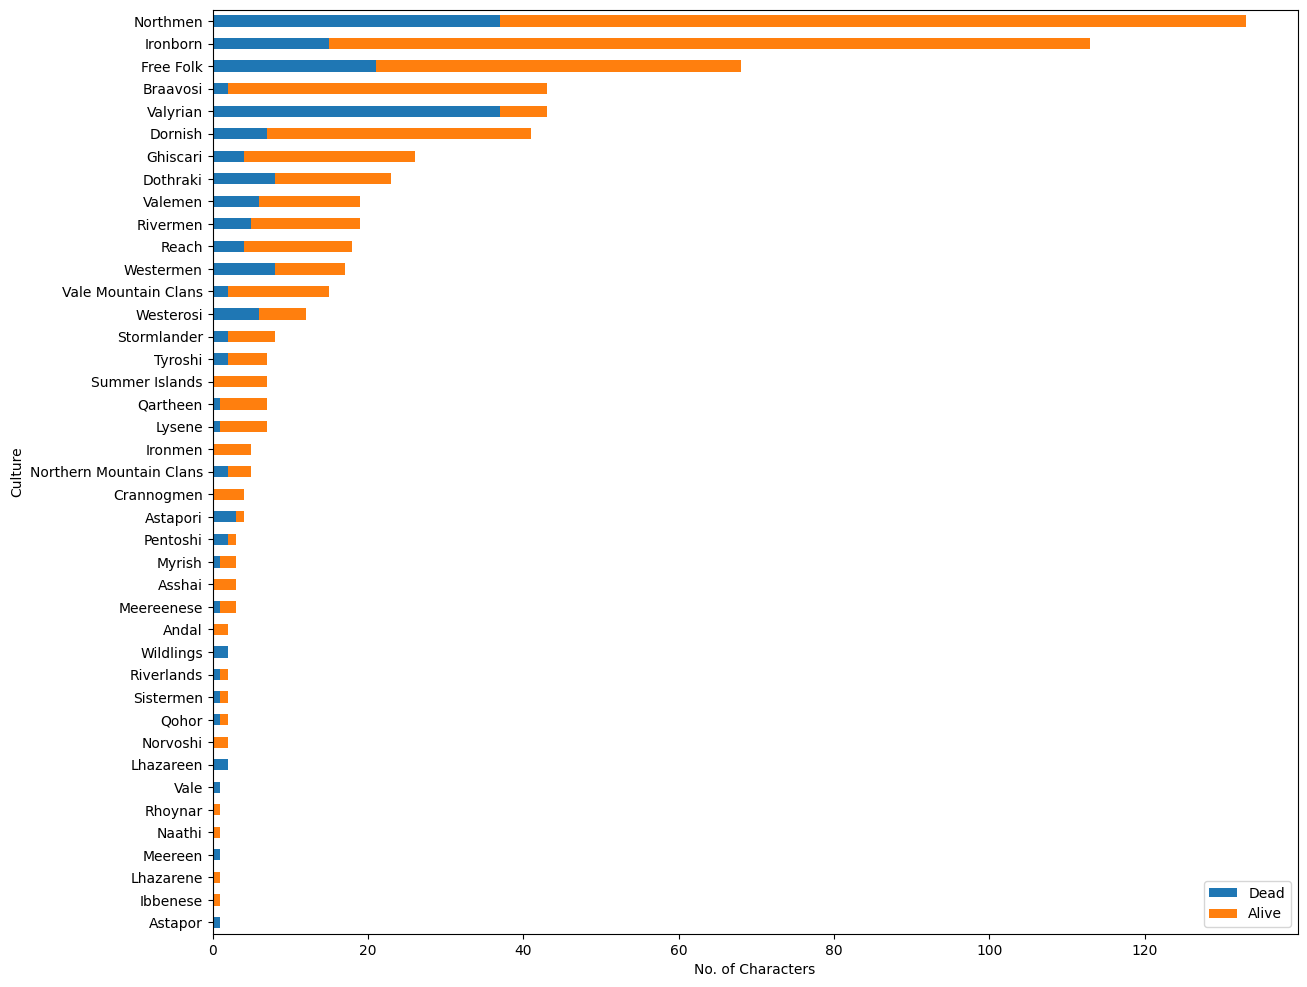

In [31]:
# Podemos visualizar la relación que existe entre el atributo culture y la supervivencia

characters.loc[:, "culture"] = [get_cult(x) for x in characters.culture.fillna("")]
data = characters.groupby(["culture", "isAlive"]).count()["name"].unstack().copy(deep = True)
data.loc[:, "total"]= data.sum(axis = 1)
p = data[data.index != ""].sort_values("total")[[0, 1]].plot.barh(stacked = True, rot = 0, figsize = (14, 12),)
_ = p.set(xlabel = "No. of Characters", ylabel = "Culture"), p.legend(["Dead", "Alive"], loc = "lower right")

# PREGUNTA 1: Examen

En el supuesto se menciona el uso de pandas.factorize() para convertir atributos categóricos a numéricos. Otra forma común y robusta de hacer esto es utilizando la librería Scikit-learn:

    LabelEncoder: Asigna un número entero único a cada categoría.

    map(): Usando un diccionario manual si existe un orden lógico.

    astype('category').cat.codes: Una función nativa de pandas muy eficiente.

In [32]:
# Convertimos atributos categóricos no numéricos a numéricos y los valores nulos se reemplazan por -1

characters.loc[:, "culture"] = [get_cult(x) for x in characters.culture.fillna("")]
characters.loc[:, "title"] = pd.factorize(characters.title)[0]
characters.loc[:, "culture"] = pd.factorize(characters.culture)[0]
characters.loc[:, "house"] = pd.factorize(characters.house)[0]

characters.columns = map(lambda x: x.replace(".", "").replace("_", ""), characters.columns)
characters.fillna(value = -1, inplace = True)

In [33]:
characters.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1946 entries, 0 to 1945
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               1946 non-null   object 
 1   title              1946 non-null   object 
 2   male               1946 non-null   int64  
 3   culture            1946 non-null   object 
 4   house              1946 non-null   object 
 5   book1              1946 non-null   int64  
 6   book2              1946 non-null   int64  
 7   book3              1946 non-null   int64  
 8   book4              1946 non-null   int64  
 9   book5              1946 non-null   int64  
 10  isMarried          1946 non-null   int64  
 11  isNoble            1946 non-null   int64  
 12  numDeadRelations   1946 non-null   int64  
 13  boolDeadRelations  1946 non-null   int64  
 14  isPopular          1946 non-null   int64  
 15  popularity         1946 non-null   float64
 16  isAlive            1946 

In [34]:
characters.head()

,name,title,male,culture,house,book1,book2,book3,book4,book5,isMarried,isNoble,numDeadRelations,boolDeadRelations,isPopular,popularity,isAlive
0,Viserys II Targaryen,-1,1,0,-1,0,0,0,0,0,0,0,11,1,1,0.605351,0
1,Walder Frey,0,1,1,0,1,1,1,1,1,1,1,1,1,1,0.896321,1
2,Addison Hill,1,1,0,1,0,0,0,1,0,0,1,0,0,0,0.267559,1
3,Aemma Arryn,2,0,0,2,0,0,0,0,0,1,1,0,0,0,0.183946,0
4,Sylva Santagar,3,0,2,3,0,0,0,1,0,1,1,0,0,0,0.043478,1


# **ANALIZANDO LOS DATOS**

# PREGUNTA 2: Examen

---

| Estado (`isAlive`) | Cantidad | Porcentaje |
| --- | --- | --- |
| **Vivo (1)** | 1,451 | 74.56% |
| **Fallecido (0)** | 495 | 25.44% |
| **Total** | **1,946** | **100.00%** |

---

Aunque no están muy desbalanceados hay un 75% de datos que están vivos frente a un 25% que no lo están luego no se consideran datos balanceados, ya que existe una diferencia clara entre las clases (aprox. 75% vs 25%). Aunque no es un desbalance extremo, sí puede afectar al rendimiento del modelo, especialmente haciendo que tienda a predecir mayoritariamente la clase mayoritaria

Solución: Si no están balanceados, aplicaría técnicas de Resampling, ajustes de peso de clase o métricas adecuadas:

    Undersampling: Eliminar registros de la clase mayoritaria.

    Oversampling (SMOTE): Generar datos sintéticos para la clase minoritaria.
    
    Ajuste de pesos de clase: Utilizar parámetros como class_weight='balanced' en algoritmos de clasificación (SVM, árboles, regresión logística), de forma que el modelo penalice más los errores en la clase minoritaria.
    
    Uso de métricas adecuadas: Priorizar métricas como recall, F1-score o AUC-ROC, en lugar de la accuracy, que puede resultar engañosa en datasets desbalanceados.
    

In [35]:
def comprobar_balance(df, target_col, umbral_alerta=70):
    """
    Analiza si una columna categórica está balanceada.

    Args:
        df (pd.DataFrame): El dataframe.
        target_col (str): Nombre de la columna objetivo (ej. 'Fatal (Y/N)').
        umbral_alerta (float): Porcentaje a partir del cual consideramos desbalanceo severo.
    """
    if target_col not in df.columns:
        print(f"Error: La columna '{target_col}' no existe.")
        return

    # Contar valores y porcentajes
    conteo = df[target_col].value_counts()
    porcentaje = df[target_col].value_counts(normalize=True) * 100

    # Crear un DataFrame resumen
    balance_df = pd.DataFrame({'Cantidad': conteo, 'Porcentaje (%)': porcentaje})

    print(f"--- Análisis de Balance: '{target_col}' ---")
    print(balance_df)
    print("\n")

    # Comprobación rápida de desbalanceo severo
    clase_dominante = porcentaje.idxmax()
    pct_dominante = porcentaje.max()

    if pct_dominante > umbral_alerta:
        print(f"ADVERTENCIA: Dataset DESBALANCEADO.")
        print(f"La clase '{clase_dominante}' domina con un {pct_dominante:.2f}%.")
        print("Modelos predictivos podrían sesgarse hacia esta clase.\n")
    else:
        print(f"El dataset parece razonablemente balanceado (Clase mayoritaria: {pct_dominante:.2f}%).\n")

    # Visualización
    plt.figure(figsize=(8, 4))
    sns.barplot(x=conteo.index, y=conteo.values, palette="viridis")
    plt.title(f'Distribución de clases en: {target_col}')
    plt.ylabel('Cantidad de registros')
    plt.xlabel('Clases')
    plt.show()

--- Análisis de Balance: 'isAlive' ---
         Cantidad  Porcentaje (%)
isAlive                          
1            1451       74.563207
0             495       25.436793


ADVERTENCIA: Dataset DESBALANCEADO.
La clase '1' domina con un 74.56%.
Modelos predictivos podrían sesgarse hacia esta clase.



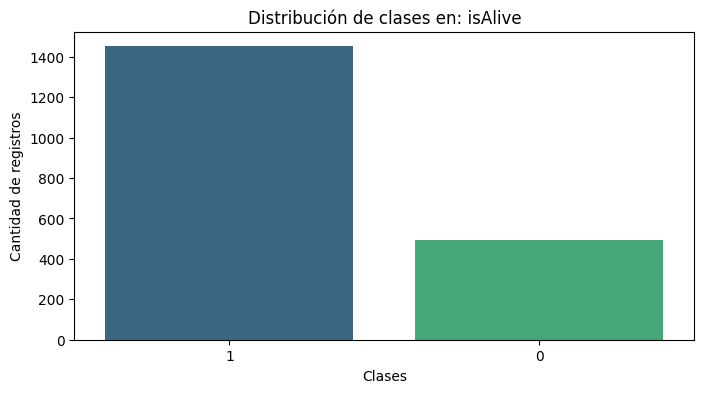

In [36]:
# Ejemplo 1: Analizar la columna (Típico target binario)
# Primero hacemos una limpieza rápida porque esta columna suele estar sucia en GSAF
characters['isAlive'] = characters['isAlive'].astype(str).str.upper().str.strip()

# Ejecutamos la función
comprobar_balance(characters, 'isAlive')

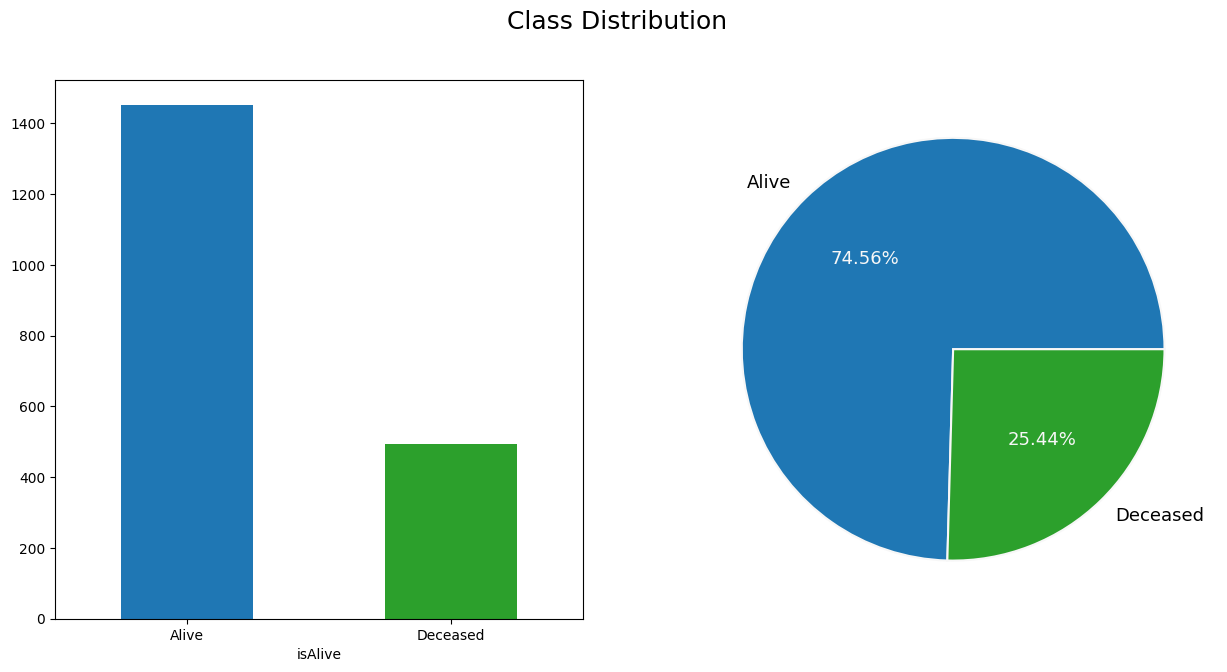

In [37]:
f, ax = plt.subplots(1, 2, figsize = (15, 7))
f.suptitle("Class Distribution", fontsize = 18.)
_ = characters.isAlive.value_counts().plot.bar(ax = ax[0], rot = 0, color = (sns.color_palette()[0], sns.color_palette()[2])).set(xticklabels = ["Alive", "Deceased"])
_ = characters.isAlive.value_counts().plot.pie(labels = ("Alive", "Deceased"), autopct = "%.2f%%", label = "", fontsize = 13., ax = ax[1],\
colors = (sns.color_palette()[0], sns.color_palette()[2]), wedgeprops = {"linewidth": 1.5, "edgecolor": "#F7F7F7"}), ax[1].texts[1].set_color("#F7F7F7"), ax[1].texts[3].set_color("#F7F7F7")

# PREGUNTA 3: Examen

No, en el supuesto no se ha aplicado One-Hot Encoding.

Lo que se ha hecho en el código es codificación por etiquetas (Label Encoding / Factorize), no One-Hot Encoding.

En su lugar, se ha utilizado codificación por etiquetas mediante pd.factorize(), que asigna valores numéricos enteros a las categorías manteniendo una única columna por atributo. Esto no equivale a One-Hot Encoding, ya que no se crean variables binarias independientes para cada categoría.

Ejemplo de One-Hot Encoding:

pd.get_dummies(characters["house"])


TypeError: violinplot() got multiple values for argument 'data'

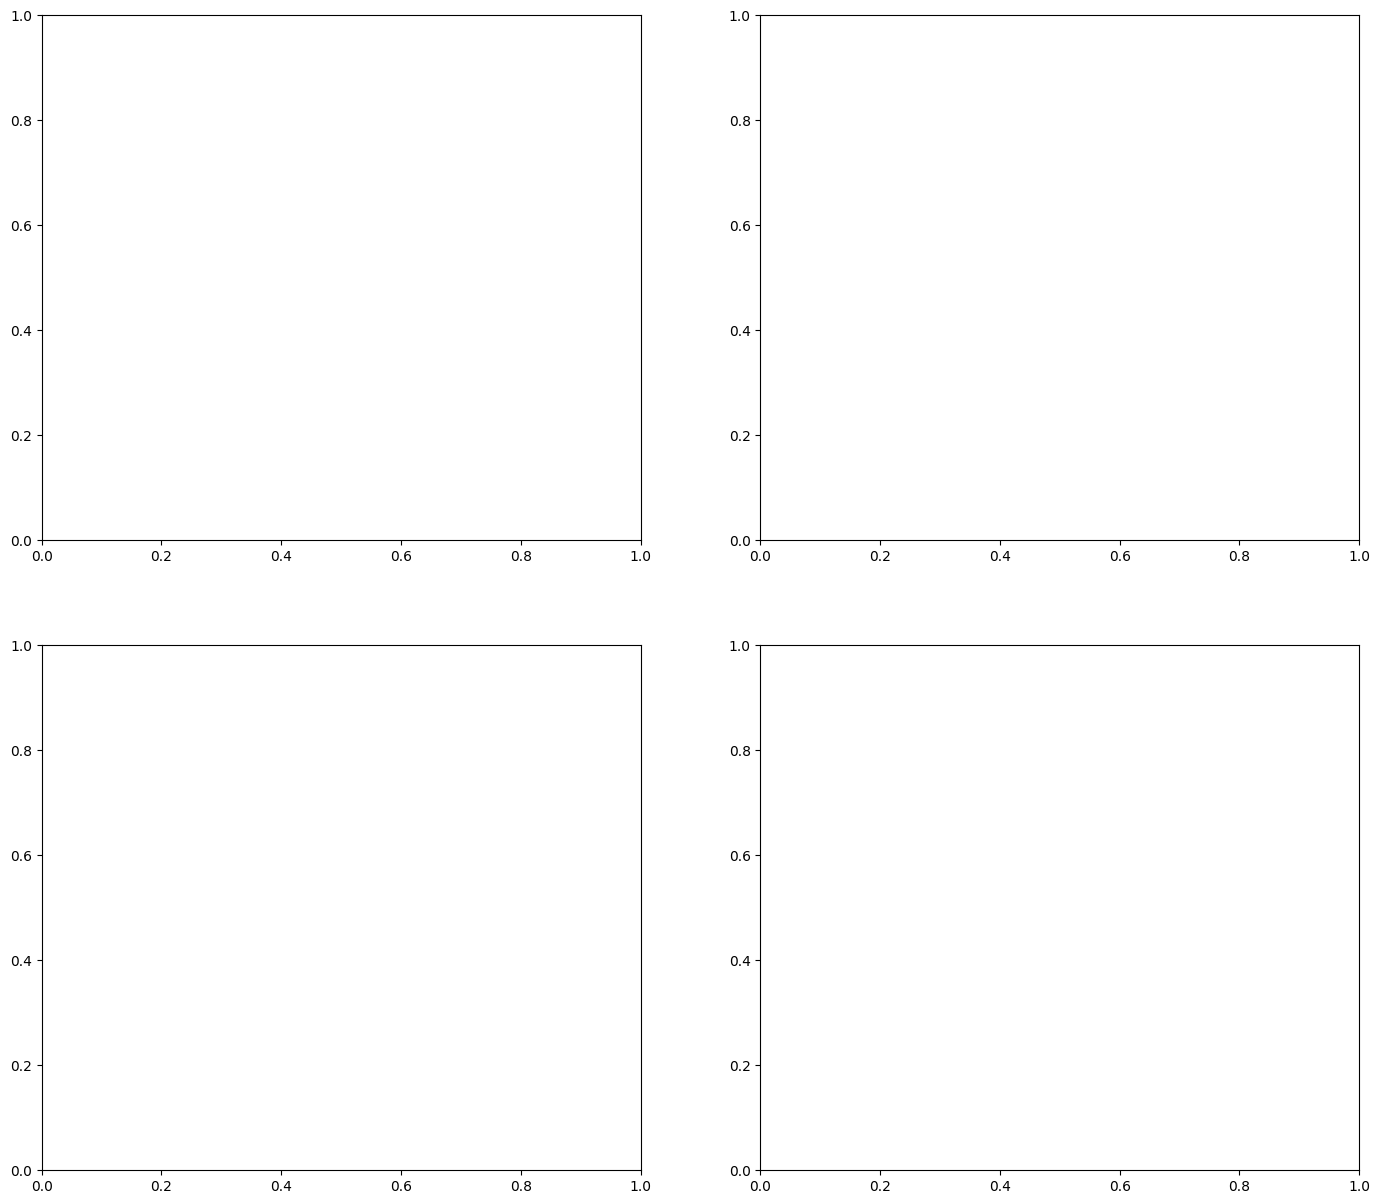

In [41]:
import warnings
warnings.filterwarnings('ignore')
f,ax=plt.subplots(2,2,figsize=(17,15))
sns.violinplot("isPopular", "isNoble", hue="isAlive", data=characters,split=True, ax=ax[0, 0])
ax[0, 0].set_title('Noble and Popular vs Mortality')
ax[0, 0].set_yticks(range(2))

sns.violinplot("isPopular", "male", hue="isAlive", data=characters ,split=True, ax=ax[0, 1])
ax[0, 1].set_title('Male and Popular vs Mortality')
ax[0, 1].set_yticks(range(2))

sns.violinplot("isPopular", "isMarried", hue="isAlive", data=characters,split=True, ax=ax[1, 0])
ax[1, 0].set_title('Married and Popular vs Mortality')
ax[1, 0].set_yticks(range(2))


sns.violinplot("isPopular", "book1", hue="isAlive", data=characters ,split=True, ax=ax[1, 1])
ax[1, 1].set_title('Book_1 and Popular vs Mortality')
ax[1, 1].set_yticks(range(2))


plt.show()

# PREGUNTA 4: Examen

1. La popularidad está fuertemente ligada a la nobleza (Gráfico Superior Izq.)
Observación: En la columna de isPopular = 0, la gran mayoría de la densidad está en isNoble = 0 (plebeyos). En cambio, en isPopular = 1, la densidad se traslada casi totalmente a isNoble = 1.

Inferencia: Es muy difícil ser un personaje "popular" si no eres noble. Casi todos los personajes populares pertenecen a la nobleza.

2. Sesgo de género en la popularidad (Gráfico Superior Der.)
Observación: Mira la columna de isPopular = 1 (derecha). La forma del violín es muy ancha en la parte superior (male = 1) y muy estrecha en la parte inferior (male = 0).

Inferencia: Hay una desproporción significativa: la inmensa mayoría de los personajes populares son hombres. Las mujeres tienen mucha menos representación dentro del grupo de "populares".

3. Los personajes populares tienden a aparecer desde el inicio (Gráfico Inferior Der.)
Observación: Esta es quizás la relación más clara. En isPopular = 0, casi nadie apareció en el Libro 1 (book1 = 0). En isPopular = 1, la gran mayoría sí apareció en el Libro 1 (book1 = 1).

Inferencia: Para ser considerado popular en este dataset, es casi un requisito haber sido presentado en el primer libro. Los personajes introducidos más tarde rara vez alcanzan el estatus de "popular".

4. Estado Civil y Popularidad (Gráfico Inferior Izq.)
Observación: Los personajes no populares son abrumadoramente solteros (isMarried = 0). Los populares tienen una distribución más mixta, aunque siguen habiendo muchos solteros.

Inferencia: Es más probable estar casado si eres un personaje popular que si no lo eres, aunque no es un determinante tan fuerte como la nobleza o la aparición en el primer libro.

# **REDUCCIÓN DIMENSIONALIDAD**

## **PCA**

In [ ]:
X = characters[['title', 'male', 'culture', 'house', 'book1', 'book2', 'book3', 'book4', 'book5', 'isMarried', 'isNoble', 'numDeadRelations', 'boolDeadRelations', 'isPopular', 'popularity']]
y = characters['isAlive']

In [ ]:
scaler = preprocessing.StandardScaler().fit(X)
X_scaled = scaler.transform(X)

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(X_scaled)
X_pca = pca.transform(X_scaled)

print("shape of X_pca", X_pca.shape)
expl = pca.explained_variance_ratio_
print(expl)
print('suma:',sum(expl[0:5]))

shape of X_pca (1946, 2)
[0.24225645 0.13156997]
suma: 0.37382642576331016


# PREGUNTA 5: Examen

La varianza explicada por cada componente es:

PCA1: ≈ 24.2%

PCA2: ≈ 13.2%

Varianza total explicada por las dos componentes:
24.2% + 13.2% ≈ 37.4%


Aunque es posible aplicar PCA con dos componentes, no es recomendable en este caso, ya que no se captura suficiente varianza del conjunto de datos. Para un análisis más representativo, sería preferible:

Aumentar el número de componentes hasta explicar al menos 70–80% de la varianza

PCA con 2 componentes es válido, pero insuficiente para este supuesto.


## **CORRELACIÓN**

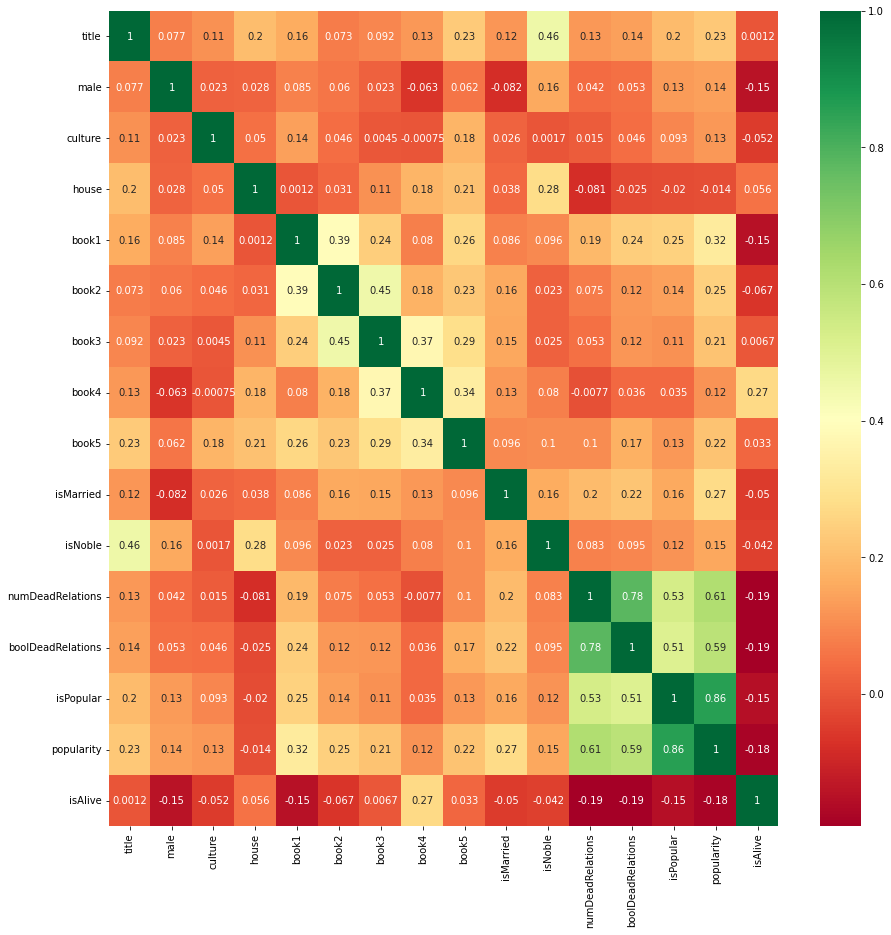

In [ ]:
plt.figure(figsize=(15,15))
g=sns.heatmap(characters.corr(), annot=True, cmap="RdYlGn")

# PREGUNTA 6: Examen

Eliminaría isPopular: Es redundante con popularity (que es numérica y aporta más detalle).

Eliminaría boolDeadRelations: Es redundante con numDeadRelations (que indica la cantidad exacta).

Eliminaría dateOfBirth: Si ya tenemos la columna age, la fecha añade ruido y suele tener muchos valores nulos (NaN).

Me quedaría con: age, popularity, numDeadRelations, isNoble, isMarried y las columnas de aparición en libros (book1...book5) ya que indican relevancia del personaje.

# PREGUNTA 7: Examen

Mejor opción: Regresión Logística.

    Explicación: La variable a predecir es isAlive, la cual es binaria (0 o 1, muerto o vivo).

    La Regresión Lineal predice valores continuos (ej. precio, temperatura), por lo que no es adecuada aquí.

    La Regresión Logística está diseñada específicamente para clasificación binaria, devolviendo la probabilidad de pertenecer a una clase (entre 0 y 1).

# **SVC (Support Vector Classification)**

In [ ]:
from sklearn.svm import SVC

X = characters[['title', 'male', 'culture', 'house', 'book1', 'book2', 'book3', 'book4', 'book5', 'isMarried', 'isNoble', 'numDeadRelations', 'boolDeadRelations', 'isPopular', 'popularity']]
y = characters['isAlive']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

clf = SVC(kernel='linear')
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(accuracy_score(y_test,y_pred))

0.7307692307692307


# **DECISION TREE**

In [ ]:
# Split data keeping 80% for training and the rest for test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
! pip install graphviz

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
from sklearn import tree
import graphviz

clf = tree.DecisionTreeClassifier(random_state=0)
#Entrenamos
clf = clf.fit(X_train, y_train)

In [ ]:
y_pred = clf.predict(X_test)
y_pred

array([1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0,

In [ ]:
print("Accuracy:", accuracy_score(y_pred, y_test))

Accuracy: 0.7307692307692307


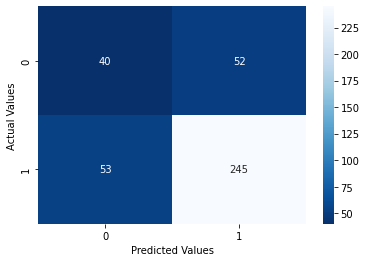

In [ ]:
cm = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap='Blues_r' ,fmt='d')
plt.ylabel("Actual Values")
plt.xlabel("Predicted Values")
plt.show()

[Text(0.5, 0.875, 'X[7] <= 0.5\ngini = 0.384\nsamples = 1556\nvalue = [403, 1153]'),
 Text(0.25, 0.625, 'X[14] <= 0.025\ngini = 0.48\nsamples = 651\nvalue = [261, 390]'),
 Text(0.125, 0.375, 'X[14] <= 0.012\ngini = 0.343\nsamples = 377\nvalue = [83, 294]'),
 Text(0.0625, 0.125, '\n  (...)  \n'),
 Text(0.1875, 0.125, '\n  (...)  \n'),
 Text(0.375, 0.375, 'X[14] <= 0.258\ngini = 0.455\nsamples = 274\nvalue = [178, 96]'),
 Text(0.3125, 0.125, '\n  (...)  \n'),
 Text(0.4375, 0.125, '\n  (...)  \n'),
 Text(0.75, 0.625, 'X[14] <= 0.065\ngini = 0.265\nsamples = 905\nvalue = [142, 763]'),
 Text(0.625, 0.375, 'X[14] <= 0.022\ngini = 0.15\nsamples = 528\nvalue = [43, 485]'),
 Text(0.5625, 0.125, '\n  (...)  \n'),
 Text(0.6875, 0.125, '\n  (...)  \n'),
 Text(0.875, 0.375, 'X[1] <= 0.5\ngini = 0.387\nsamples = 377\nvalue = [99, 278]'),
 Text(0.8125, 0.125, '\n  (...)  \n'),
 Text(0.9375, 0.125, '\n  (...)  \n')]

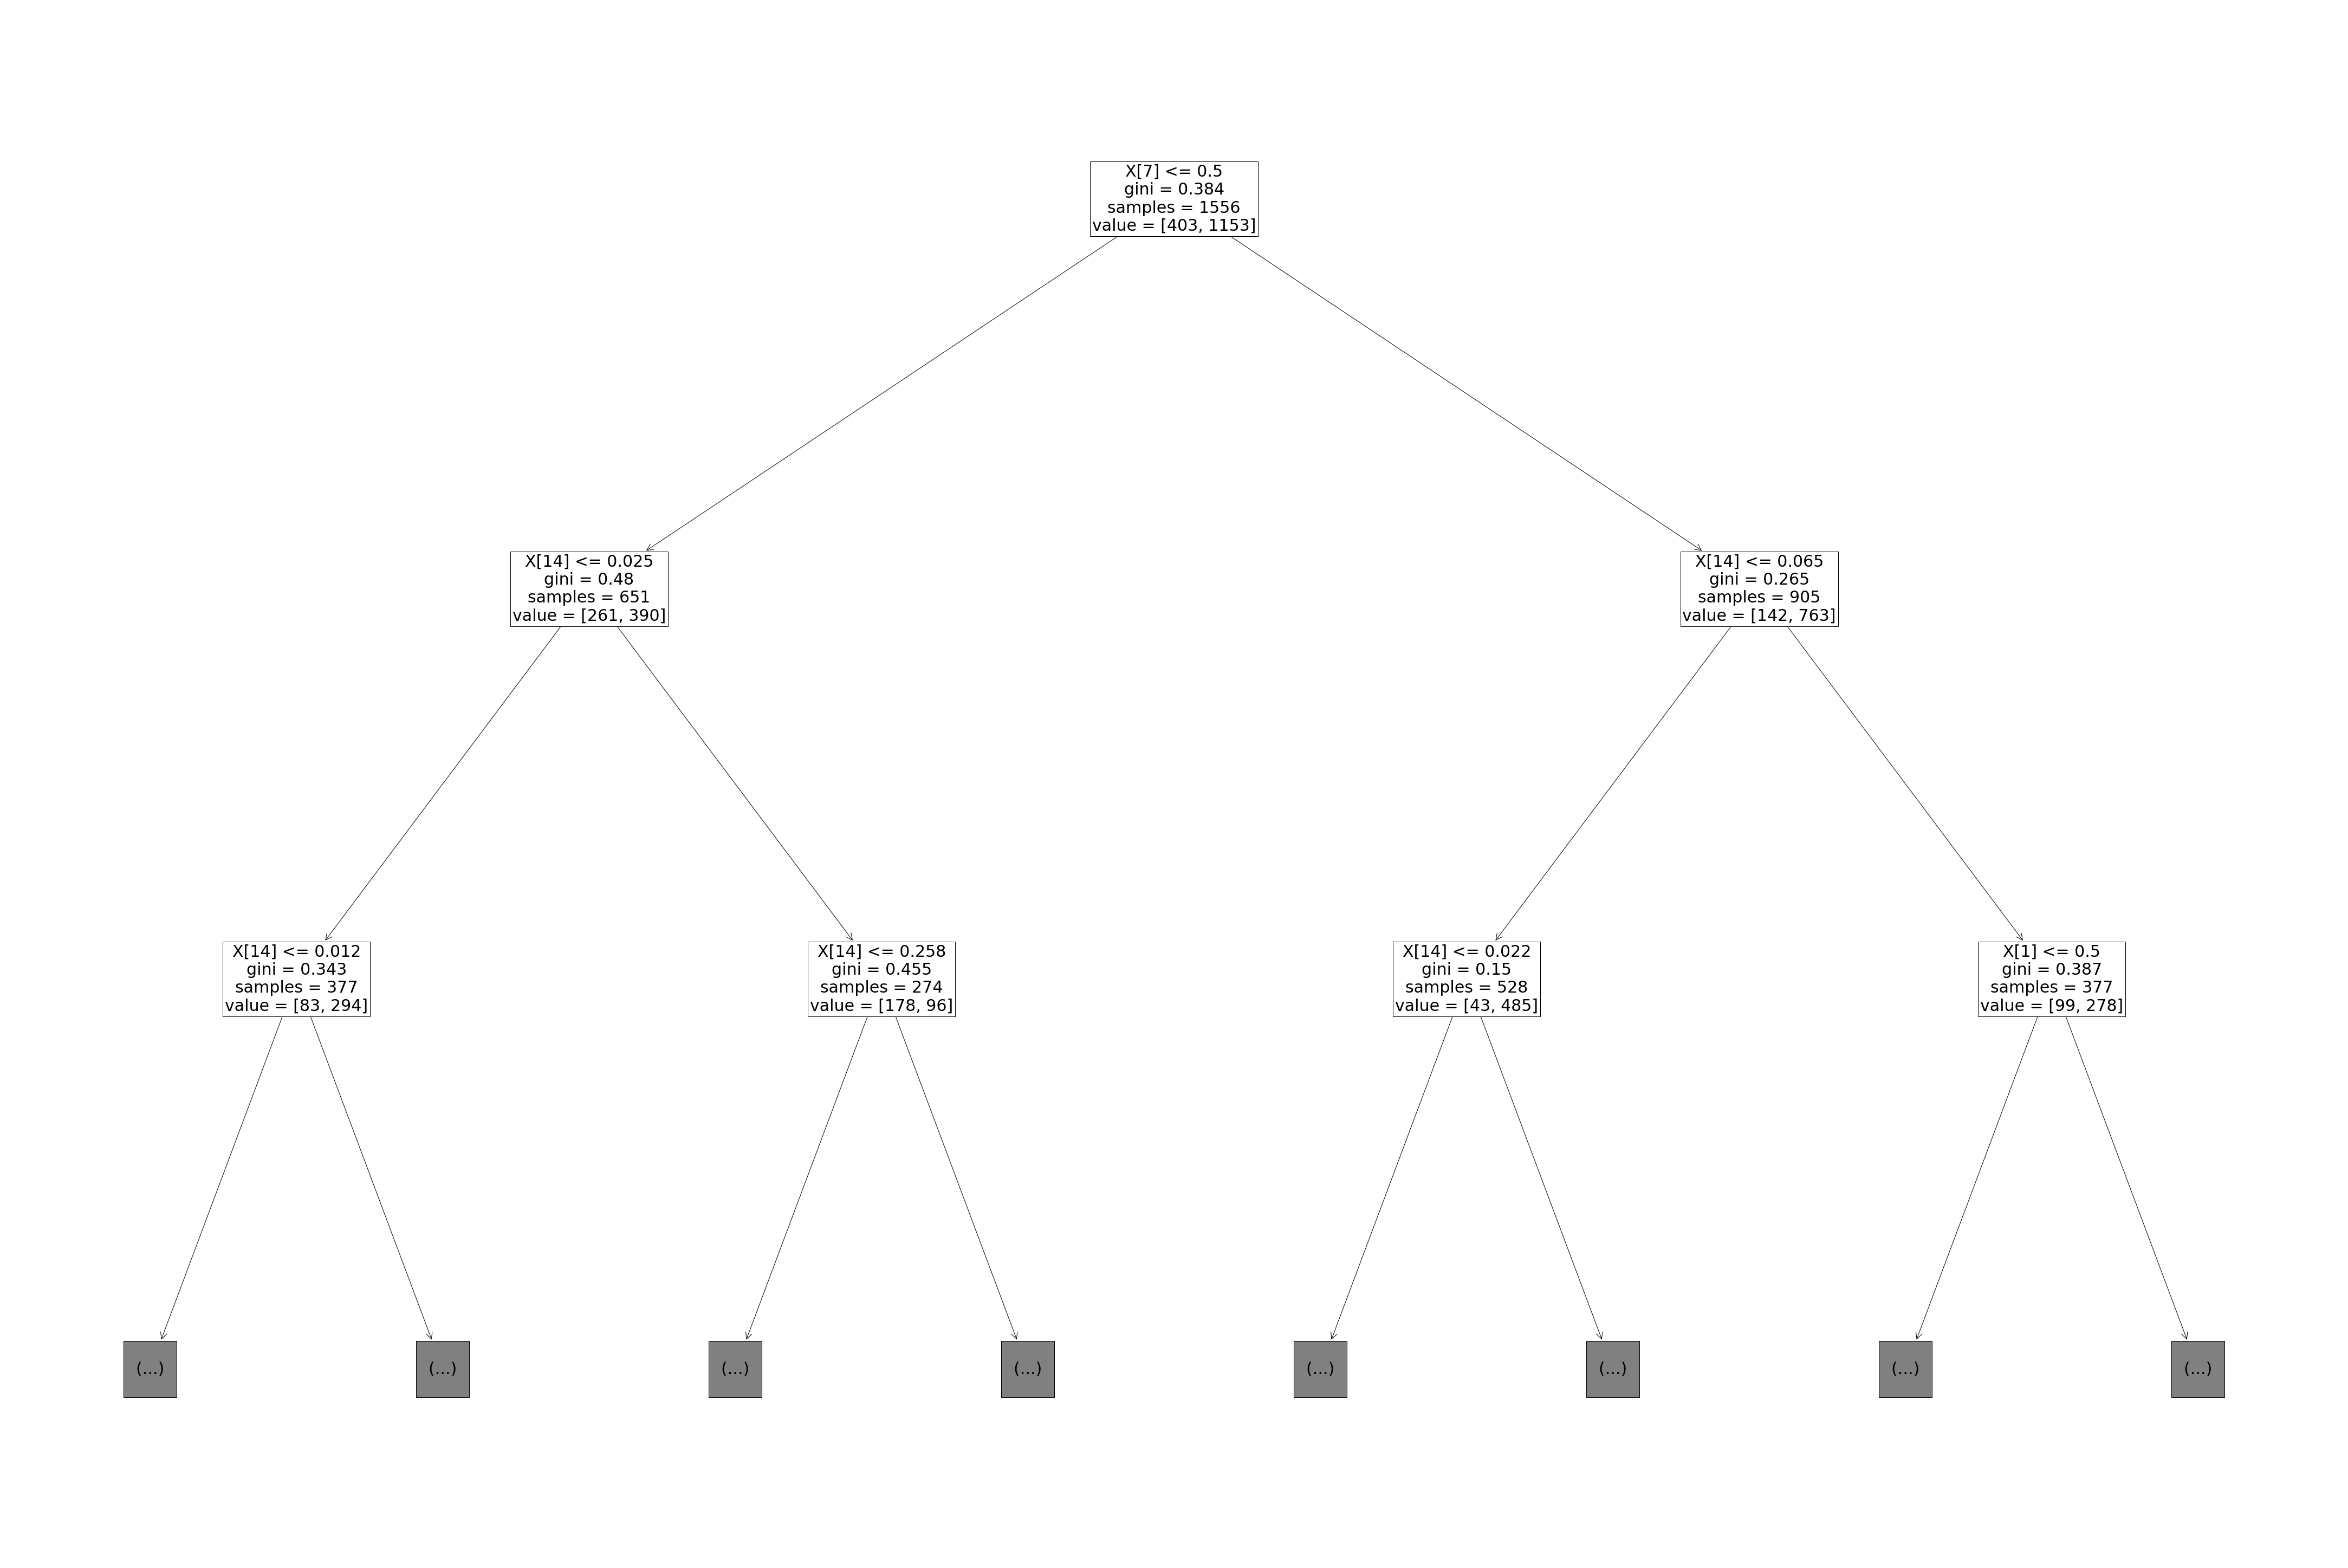

In [ ]:
fig = plt.figure()
ax = fig.add_axes([0,0,10,10])
tree.plot_tree(clf,fontsize=30,ax=ax,max_depth=2)

# **CLUSTERING**

In [ ]:
# Vamos a eliminar varios atributos
df_clu = characters.drop(['name', 'title', 'boolDeadRelations'] , axis=1)
# Y en vez de book1, book2, book3, book4, book5 lo sustituimos por en cuantos libros aparece el personaje
df_clu['numBooks'] = df_clu.book1 + df_clu.book2 + df_clu.book3 + df_clu.book4 + df_clu.book5
df_clu = df_clu.drop(['book1', 'book2', 'book3', 'book4', 'book5'] , axis=1)
df_clu.head(9)

,male,culture,house,isMarried,isNoble,numDeadRelations,isPopular,popularity,isAlive,numBooks
0,1,0,-1,0,0,11,1,0.605351,0,0
1,1,1,0,1,1,1,1,0.896321,1,5
2,1,0,1,0,1,0,0,0.267559,1,1
3,0,0,2,1,1,0,0,0.183946,0,0
4,0,2,3,1,1,0,0,0.043478,1,1
5,1,0,-1,0,0,5,1,1.000000,1,0
6,1,3,4,1,1,0,1,0.431438,0,0
7,1,0,-1,0,0,5,1,0.678930,0,0
8,1,0,-1,0,1,0,0,0.006689,0,1


In [ ]:
min_max_scaler = preprocessing.MinMaxScaler()
df = min_max_scaler.fit_transform(df_clu)
df = pd.DataFrame(df)

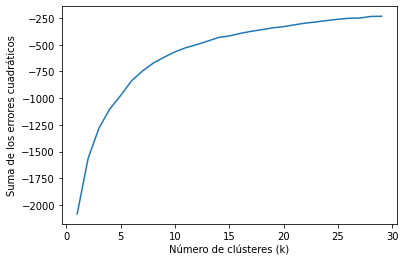

In [ ]:
from sklearn.cluster import KMeans

nc = range(1, 30) # El número de iteraciones que queremos hacer.
kmeans = [KMeans(n_clusters=i) for i in nc]
score = [kmeans[i].fit(df).score(df) for i in range(len(kmeans))]
score
plt.xlabel('Número de clústeres (k)')
plt.ylabel('Suma de los errores cuadráticos')
plt.plot(nc,score)

In [ ]:
kmeans = KMeans(n_clusters=5).fit(df)
centroids = kmeans.cluster_centers_
print(centroids)

[[ 1.00000000e+00  7.42574257e-02  1.36138614e-01  4.95049505e-02
  -3.88578059e-16  4.78547855e-03  1.48514851e-02  5.40332461e-02
   1.00000000e+00  3.71287129e-01]
 [ 1.22124533e-15  6.79832545e-02  2.74667728e-01  2.42537313e-01
   1.00000000e+00  3.48258706e-02  4.10447761e-02  8.04797085e-02
   8.09701493e-01  3.99253731e-01]
 [ 1.00000000e+00  7.72732382e-02  3.03436965e-01  1.58986175e-01
   1.00000000e+00  1.76651306e-02  8.29493088e-02  1.10722377e-01
   1.00000000e+00  4.76958525e-01]
 [ 8.26576577e-01  8.92111624e-02  1.85547940e-01  1.35135135e-01
   4.39189189e-01  4.42942943e-02  1.32882883e-01  1.43398415e-01
  -3.21964677e-15  3.96846847e-01]
 [-6.66133815e-16  6.58413402e-02  1.56551102e-01  1.56565657e-01
  -4.44089210e-16  2.69360269e-03  7.57575758e-03  4.85118746e-02
   1.00000000e+00  3.88888889e-01]]


# PREGUNTA 8: Examen

Para hallar el número óptimo de clusters en lugar de asumir 5, se utiliza el Método del Codo (Elbow Method).

    Se ejecuta el algoritmo (K-Means) con diferentes valores de k.

    Se grafica la "Suma de Errores Cuadráticos" (WCSS) frente a k.

    El punto donde la curva deja de bajar drásticamente y se aplana (formando un codo) es el número óptimo.

# **RANDOM FOREST CLASSIFIER**

In [ ]:
# Split data keeping 80% for training and the rest for test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

seed = 42
np.random.seed(seed)

# Definimos el algoritmo
bar = RandomForestClassifier(n_estimators=400, n_jobs=-1, random_state=seed)
# Lo entrenamos
bar.fit(X_train, y_train)
# Realizamos la predicción
Y_prob = bar.predict_proba(X_test)
Y_pred = np.argmax(Y_prob, axis=1)

In [ ]:
print('Precisión del modelo:')
print(bar.score(X_train, y_train))

Precisión del modelo:
0.9916452442159382


# PREGUNTA 9: Examen

Se ha aplicado Classifier porque el objetivo es predecir una clase categórica (isAlive: Vivo/Muerto).

    RandomForestRegressor se usaría si quisiéramos predecir un valor numérico continuo, como la edad exacta de muerte o el puntaje de popularidad.

## **Confusion Matrix**

[Text(33.0, 0.5, 'Actual Class'), Text(0.5, 15.0, 'Predicted Class')]

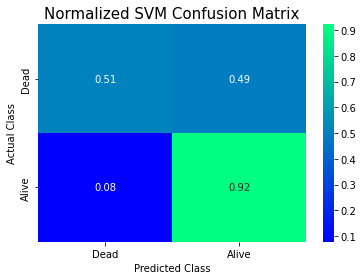

In [ ]:
cm = confusion_matrix(y_test, Y_pred)
cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

classes = ["Dead", "Alive"]
f, ax = plt.subplots()
ax.set_title("Normalized SVM Confusion Matrix", fontsize=15.)
sns.heatmap(pd.DataFrame(cm, index=classes, columns=classes),
            cmap='winter', annot=True, fmt='.2f', ax=ax).set(xlabel="Predicted Class", ylabel="Actual Class")

# PREGUNTA 10: Examen

La matriz muestra un modelo muy desbalanceado con un buen rendimiento en una clase y pésimo en la otra:

Excelente para la clase "Alive": El modelo detecta correctamente el 92% de los casos reales de "Alive".

Deficiente para la clase "Dead": El modelo solo acierta el 51% de los casos "Dead". Lo grave es que clasifica erróneamente al 49% de los "Dead" como "Alive".

Conclusión: El modelo tiene un fuerte sesgo hacia la clase "Alive" (probablemente porque hay más datos de esa clase) y no es fiable para detectar la clase "Dead"

# **DEEP LEARNING**

# PREGUNTA 11: Examen

Se usa la función sigmoide en la última capa porque estamos ante un problema de clasificación binaria.

    La sigmoide comprime la salida de la neurona a un rango entre 0 y 1.

    Esto permite interpretar la salida directamente como una probabilidad de que el personaje esté vivo (isAlive = 1).

In [42]:
X = characters[['title', 'male', 'culture', 'house', 'book1', 'book2', 'book3', 'book4', 'book5', 'isMarried', 'isNoble', 'numDeadRelations', 'boolDeadRelations', 'isPopular', 'popularity']]
y = characters['isAlive']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X.values, y.values, test_size=0.2)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from keras.models import Sequential
from keras.layers import Dense

model = Sequential()
model.add(Dense(15, input_dim=10, activation='relu'))
model.add(Dense(15, activation='relu'))
model.add(Dense(15, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 15)                240       
                                                                 
 dense_1 (Dense)             (None, 15)                240       
                                                                 
 dense_2 (Dense)             (None, 15)                240       
                                                                 
 dense_3 (Dense)             (None, 1)                 16        
                                                                 
Total params: 736
Trainable params: 736
Non-trainable params: 0
_________________________________________________________________


In [ ]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
model.fit(X_train, y_train, epochs=100, batch_size=50, verbose=1)

Epoch 1/100
32/32 [==============================] - 3s 5ms/step - loss: 0.6531 - accuracy: 0.6697
Epoch 2/100
32/32 [==============================] - 0s 6ms/step - loss: 0.5815 - accuracy: 0.7506
Epoch 3/100
32/32 [==============================] - 0s 5ms/step - loss: 0.5386 - accuracy: 0.7571
Epoch 4/100
32/32 [==============================] - 0s 11ms/step - loss: 0.5141 - accuracy: 0.7648
Epoch 5/100
32/32 [==============================] - 0s 12ms/step - loss: 0.5003 - accuracy: 0.7699
Epoch 6/100
32/32 [==============================] - 0s 12ms/step - loss: 0.4901 - accuracy: 0.7744
Epoch 7/100
32/32 [==============================] - 0s 9ms/step - loss: 0.4833 - accuracy: 0.7789
Epoch 8/100
32/32 [==============================] - 0s 4ms/step - loss: 0.4787 - accuracy: 0.7821
Epoch 9/100
32/32 [==============================] - 0s 8ms/step - loss: 0.4747 - accuracy: 0.7802
Epoch 10/100
32/32 [==============================] - 0s 5ms/step - loss: 0.4711 - accuracy: 0.7828
Epoch 

In [ ]:
y_pred = model.predict(X_test)
y_pred = y_pred > 0.5

In [ ]:
score = accuracy_score(y_test, y_pred)
'Accuracy score: %.2f' % (score * 100)

'Accuracy score: 81.03'

# PREGUNTA 12: Examen

La red neuronal presenta varios fallos. En primer lugar, la dimensión de entrada es incorrecta, ya que se define input_dim=10 cuando el conjunto de datos contiene 15 variables, lo que genera una inconsistencia. Además, se tratan variables categóricas como valores numéricos, lo cual es incorrecto, por lo que deberían codificarse mediante One-Hot Encoding.

También falta un random_state en la partición de los datos, lo que impide reproducir los resultados. La arquitectura utilizada es excesiva para un problema de clasificación binaria y puede provocar sobreajuste, por lo que conviene simplificarla. Por último, el conjunto de datos está desbalanceado y se evalúa solo con accuracy, métrica poco representativa en este caso, siendo recomendable usar métricas adicionales y validación.

# PREGUNTA 13: Examen

Random Forest es la que da mejor resultado con un 99% pero puede que tenga overfitting